In [4]:
# ---------------- Imports ----------------
import os
import json
import sys

from datetime import datetime

import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.spatial.distance import cosine
from scipy.stats import ttest_rel, wilcoxon
from sentence_transformers import SentenceTransformer



In [5]:
# ---------------- Config ----------------
with open("../../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

proj_store = config["paths"]["proj_store"]
data_path = os.path.join(proj_store, "data")
models_folderpath = config["paths"]["models"]



output_figures = os.path.join(proj_store, "evaluation", "figures")
os.makedirs(output_figures, exist_ok=True)


# File paths (replace with actual paths)
files = {
    "LLaMA-3-8B": f"{proj_store}/results/similarity_summaries/2025_05_15_16_54_53_similarity_summary_llama_3_8b_instruct_by_domain.csv",
    "DeepSeek-8B": f"{proj_store}/results/similarity_summaries/2025_05_16_14_28_07_similarity_summary_deepseek_r1_distill_llama_8b_by_domain.csv",
    #"LLaMA-3.2-3B": f"{proj_store}/results/similary_summaries/2025_05_15_16_55_33_similarity_summary_llama_3_2_3b_instruct_by_domain.csv",
}

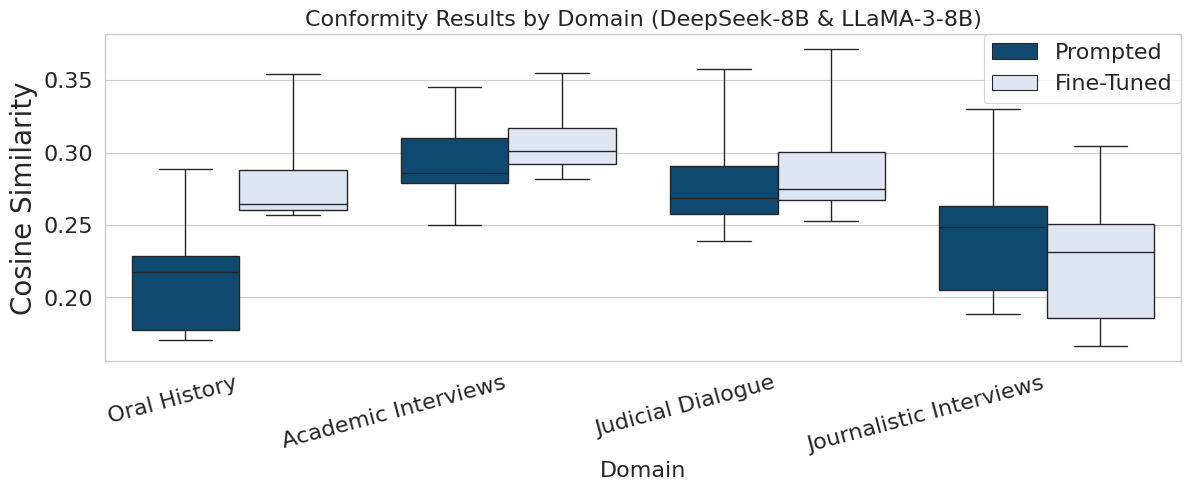

In [6]:

# Set conservative style
sns.set_theme(style="whitegrid", context="paper", font_scale=1)


df_list = []
for model_name, file in files.items():
    df = pd.read_csv(file)
    df["model"] = model_name
    df_list.append(df)
data = pd.concat(df_list, ignore_index=True)

# Reshape
melted = pd.melt(
    data,
    id_vars=["model", "domain", "embedding_model"],
    value_vars=["mean_prompted", "mean_finetuned"],
    var_name="Setting",
    value_name="Cosine Similarity"
)

# Label cleaning
melted["Setting"] = melted["Setting"].replace({
    "mean_prompted": "Prompted",
    "mean_finetuned": "Fine-Tuned"
})

domain_label_map = {
    "oral_history": "Oral History",
    "academic_interviews": "Academic Interviews",
    "judicial_dialogue": "Judicial Dialogue",
    "journalistic_interviews": "Journalistic Interviews"
}
melted["domain"] = melted["domain"].replace(domain_label_map)
domain_order = list(domain_label_map.values())

# Plot: Clean boxplot with full range
plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=melted,
    x="domain",
    y="Cosine Similarity",
    hue="Setting",
    palette=["#004C80", "#DBE6F4"],
    order=domain_order,
    whis=[0, 100],       # Full min-max range
    showfliers=False     # Optional, not needed when full range is shown
)


# Labeling
plt.title("Conformity Results by Domain (DeepSeek-8B & LLaMA-3-8B)", fontsize=16)
plt.xlabel("Domain", fontsize=16)
plt.ylabel("Cosine Similarity", fontsize=20)
plt.xticks(rotation=15, ha="right")

# Set tick label font sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Legend formatting
plt.legend(
    title_fontsize=16,
    fontsize=16,
    loc="upper right",
    borderaxespad=0
)
plt.tight_layout()

plt.savefig(f"{output_figures}/results_distribution.pdf", format="pdf", bbox_inches="tight")

plt.show()

